# **RAVDESS DATASET**

Ryerson Audio-Visual Database of Emotional Speech and Song

---

The dataset includes 1,440 audio files featuring 24 professional actors (12 females and 12 males). These actors performed two lexically-matched statements in a neutral North American accent, expressing eight emotions: Neutral, Calm, Happy, Sad, Angry, Fearful, Disgust, and Surprised. Each emotion was conveyed at two intensity levels (Normal and Strong), and was repeated twice by each actor to ensure consistency and reliability.


## Imports

In [1]:
import pandas as pd
from scipy.io import wavfile
import seaborn as sns
import matplotlib.pyplot as plt
import parselmouth
import numpy as np
import os
import librosa
from IPython import display as ipd

In [ ]:
# !pip install praat-parselmouth

In [ ]:
# !pip install librosa

In [ ]:
# !pip install resampy

## Reading the Data

In [2]:
# Create DataFrame with index `File_Name`
df = pd.read_csv('audio.csv')
df.set_index('File_Name', inplace=True)

In [3]:
# Show current DF
df.head()

,Actor,Gender,Emotion,Intensity,Statement,Repetition
File_Name,,,,,,
03-01-01-01-01-01-01.wav,1,M,neutral,normal,1,1
03-01-01-01-01-02-01.wav,1,M,neutral,normal,1,2
03-01-01-01-02-01-01.wav,1,M,neutral,normal,2,1
03-01-01-01-02-02-01.wav,1,M,neutral,normal,2,2
03-01-02-01-01-01-01.wav,1,M,calm,normal,1,1


In [4]:
df.describe()

,Actor,Statement,Repetition
count,1440.000000,1440.000000,1440.000000
mean,12.500000,1.500000,1.500000
std,6.924591,0.500174,0.500174
min,1.000000,1.000000,1.000000
25%,6.750000,1.000000,1.000000
50%,12.500000,1.500000,1.500000
75%,18.250000,2.000000,2.000000
max,24.000000,2.000000,2.000000


In [5]:
# Read WAV files
for f in df.index:
    rate, signal = wavfile.read('data/'+f)
    # Measure length of each audio file
    df.at[f, 'length'] = signal.shape[0]/rate

C:\Users\barry\AppData\Local\Temp\ipykernel_22868\4201303314.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, signal = wavfile.read('data/'+f)
C:\Users\barry\AppData\Local\Temp\ipykernel_22868\4201303314.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, signal = wavfile.read('data/'+f)


In [6]:
# Print all unique emotions in the dataset
print(df['Emotion'].unique())
class_distribution = df['Emotion'].value_counts()
print(class_distribution)

['neutral' 'calm' 'happy' 'sad' 'angry' 'fearful' 'disgust' 'surprised']
Emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


In [7]:
# Oversampling
max_count = class_distribution.max()

balanced_df = pd.DataFrame()

for label in class_distribution.index:
    label_df = df[df['Emotion'] == label]
    # Oversample if the current class has less than max_count
    if len(label_df) < max_count:
        label_df = label_df.sample(max_count, replace=True)
    balanced_df = pd.concat([balanced_df, label_df], ignore_index=True)

# Check balanced_df
print(balanced_df['Emotion'].value_counts())

Emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral      192
Name: count, dtype: int64


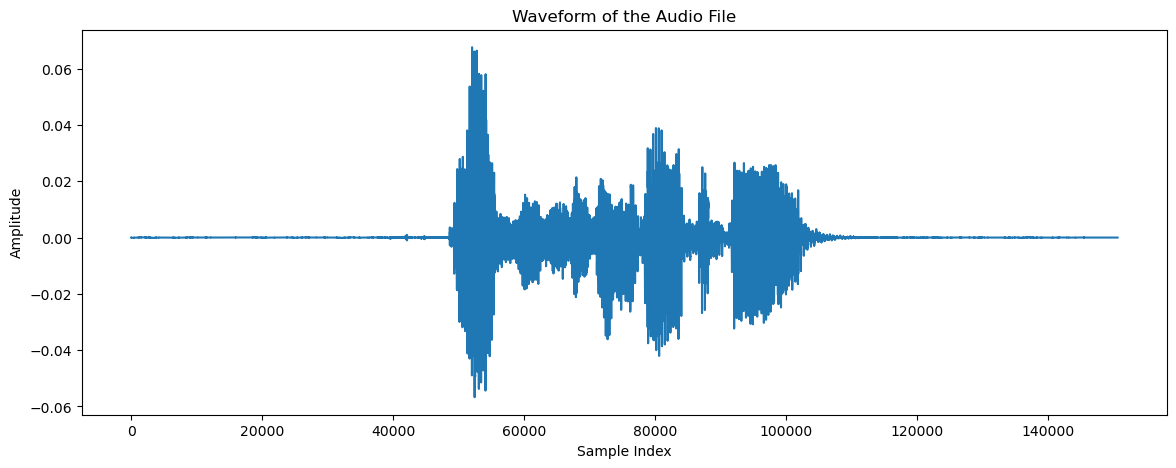

In [8]:
# Sample waveplot

# Load the audio file
file_path = 'data/03-01-03-01-02-01-13.wav'
sound = parselmouth.Sound(file_path)
audio_array = sound.values.T.flatten()

# Plot the waveform
plt.figure(figsize=(14, 5))
plt.plot(audio_array)
plt.title('Waveform of the Audio File')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

ipd.Audio(file_path)

## EDA

### Distribution of emotions in the dataset

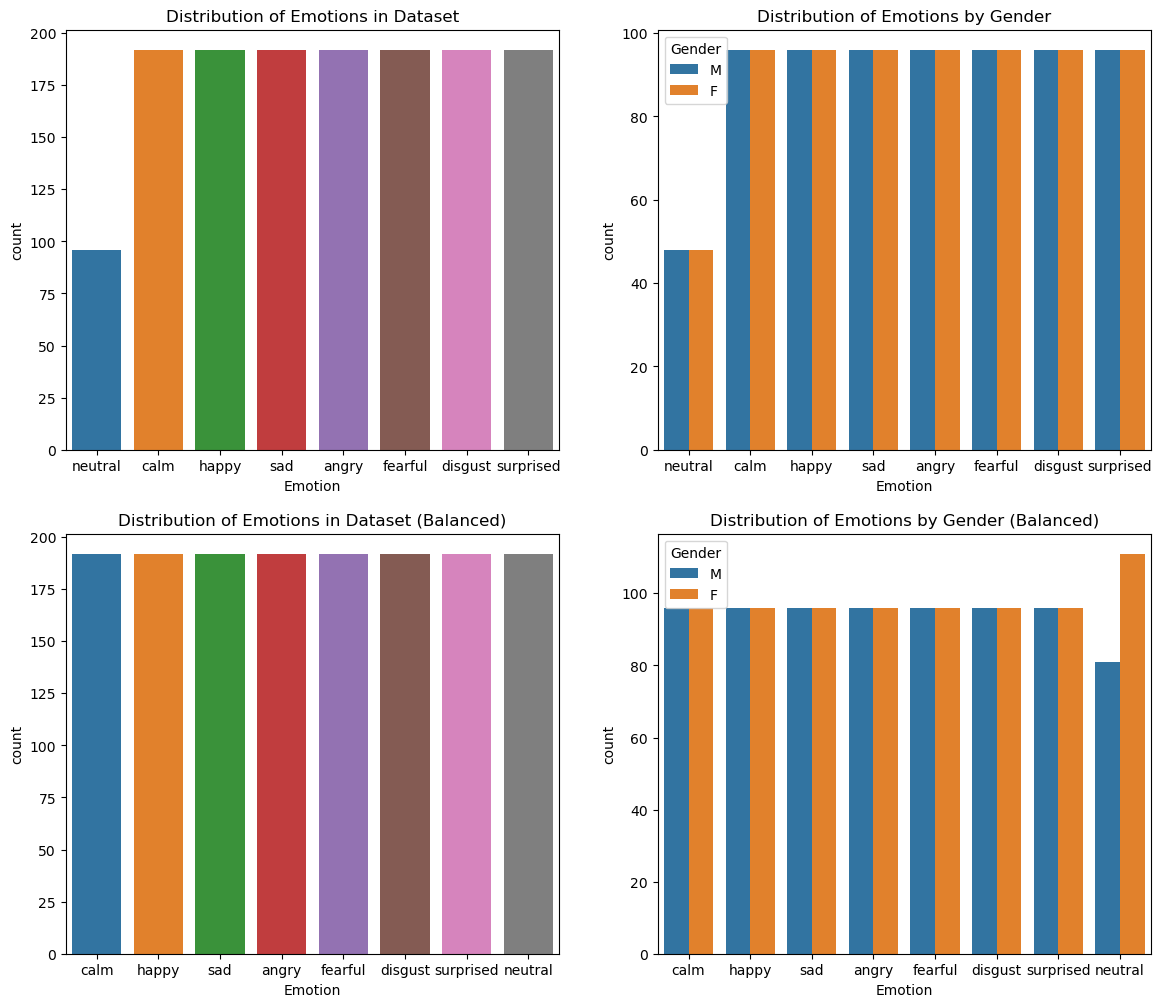

In [9]:
# Distribution of emotions in the dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
sns.countplot(x='Emotion', data=df, ax=axes[0,0])
axes[0,0].set_title("Distribution of Emotions in Dataset")

# Distribution of emotions in the dataset by Gender
sns.countplot(x='Emotion', hue='Gender', data=df, ax=axes[0,1])
axes[0,1].set_title("Distribution of Emotions by Gender")

# Distribution of emotions in the dataset (Balanced)
sns.countplot(x='Emotion', data=balanced_df, ax=axes[1,0])
axes[1,0].set_title("Distribution of Emotions in Dataset (Balanced)")

# Distribution of emotions in the dataset by Gender (Balanced)
sns.countplot(x='Emotion', hue='Gender', data=balanced_df, ax=axes[1,1])
axes[1,1].set_title("Distribution of Emotions by Gender (Balanced)")

plt.show()

The **first plot** reveals that the eight emotions are equally represented with 192 samples each, ensuring a balanced dataset for emotional expression. However, the Neutral emotion stands out with only 96 samples, which is half the count of the other emotions. This disparity suggests that while various emotions are well-represented, Neutral may be less emphasized in the dataset and could affect how we interpret and draw conclusions. The **second plot** further enhances this understanding by showing how these emotional distributions vary between genders, allowing for insights into potential differences in emotional expression across male and female participants.


### Duration of audio files

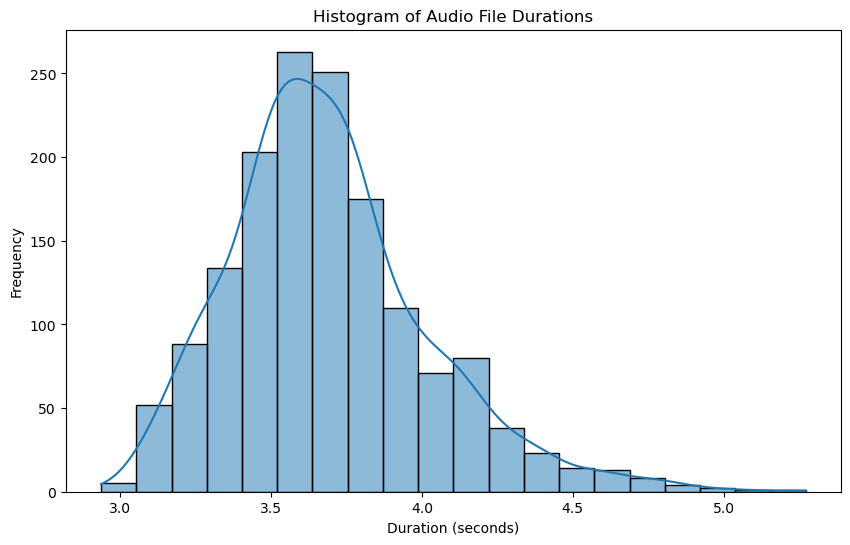

In [11]:
# What is the duration of the audio files?
plt.figure(figsize=(10, 6))
sns.histplot(balanced_df['length'], bins=20, kde=True)
plt.title('Histogram of Audio File Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

The histogram indicate that the highest **frequency of audio file durations** is observed at **3.5 seconds**, with the majority of samples falling within the range of 3.0 to 5.0 seconds. 
The peak at 3.5 seconds suggests that this duration is common for the audio files, possibly due to typical needs for this type of content. The range of 3.0 to 5.0 seconds shows that most audio files are fairly similar in lengt.


### Features

#### Mean Pitch

In [12]:
# Directory
audio_dir = "data/"

# List to store pitch data for each file
pitch_data = []

audio_files = [f for f in os.listdir(audio_dir) if f.endswith(".wav")]

for file in audio_files:
    # Load
    snd = parselmouth.Sound(os.path.join(audio_dir, file))
    # Extract pitch
    pitch = snd.to_pitch()
    pitch_values = pitch.selected_array['frequency']
    # Get mean
    pitch_mean = np.mean(pitch_values)
    # Add to df
    df.at[file, 'Mean Pitch'] = pitch_mean
    balanced_df.at[file, 'Mean Pitch'] = pitch_mean


#### Mean Intensity

In [13]:
# Directory
audio_dir = "data/"

# List to store intensity data for each file
intensity_data = []

audio_files = [f for f in os.listdir(audio_dir) if f.endswith(".wav")]

for file in audio_files:
    # Load
    snd = parselmouth.Sound(os.path.join(audio_dir, file))
    # Extract intensity
    intensity = snd.to_intensity()
    intensity_values = intensity.values.T.flatten()
    # Get Mean
    intensity_mean = np.mean(intensity_values)
    # Add to df
    df.at[file, 'Mean Intensity'] = intensity_mean
    balanced_df.at[file, 'Mean Intensity'] = intensity_mean

In [14]:
# Check modified/updated df
balanced_df.head()

,Actor,Gender,Emotion,Intensity,Statement,Repetition,length,Mean Pitch,Mean Intensity
File_Name,,,,,,,,,
03-01-02-01-01-01-01.wav,1.0,M,calm,normal,1.0,1.0,3.536854,39.075821,12.647445
03-01-02-01-01-02-01.wav,1.0,M,calm,normal,1.0,2.0,3.603583,37.766099,13.458877
03-01-02-01-02-01-01.wav,1.0,M,calm,normal,2.0,1.0,3.503500,38.531925,17.420081
03-01-02-01-02-02-01.wav,1.0,M,calm,normal,2.0,2.0,3.470146,39.616941,18.176823
03-01-02-02-01-01-01.wav,1.0,M,calm,strong,1.0,1.0,3.703708,39.217590,13.977131


#### Mel-Frequency Cepstral Coefficients (MFCC)

Another feature extracted is MFCC, which is widely used in speech recognition and audio processing. It represents the spectral characteristics of sound in a way that is well-suited for various machine-learning tasks.

In this section, we examine happiness in male and female voices. Using Librosa, we load 2.5-second audio samples at 44,100 Hz and calculate the Mel-frequency cepstral coefficients (MFCCs) for vocal characteristics. We visualize waveforms and plot MFCCs to compare vocal features of happiness across genders. This consistent approach makes it easy to analyze and interpret emotional expressions.

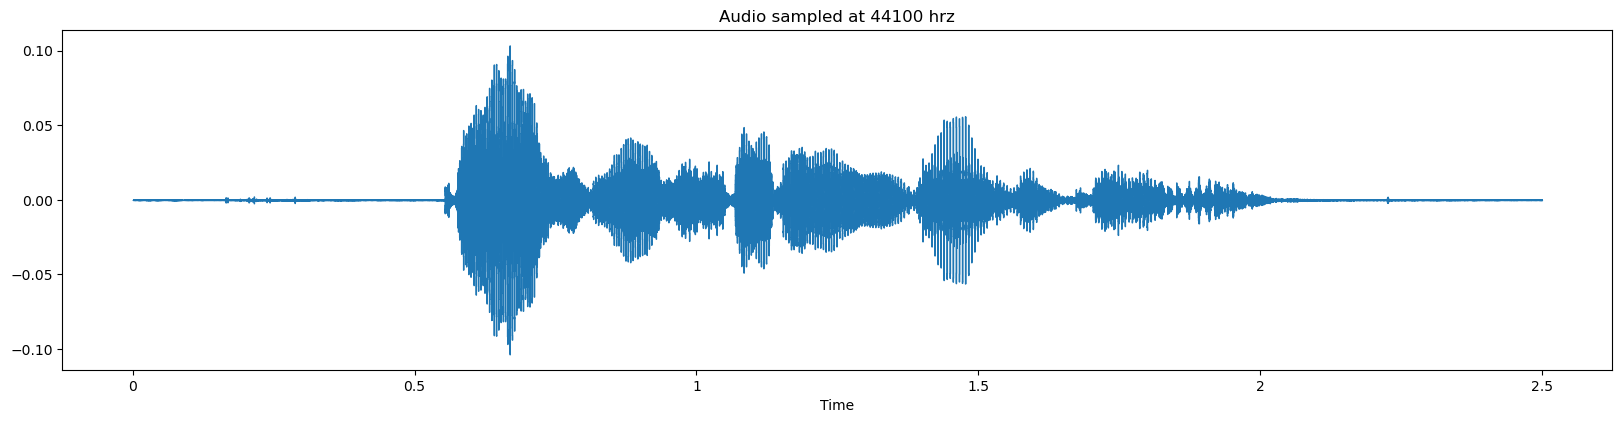

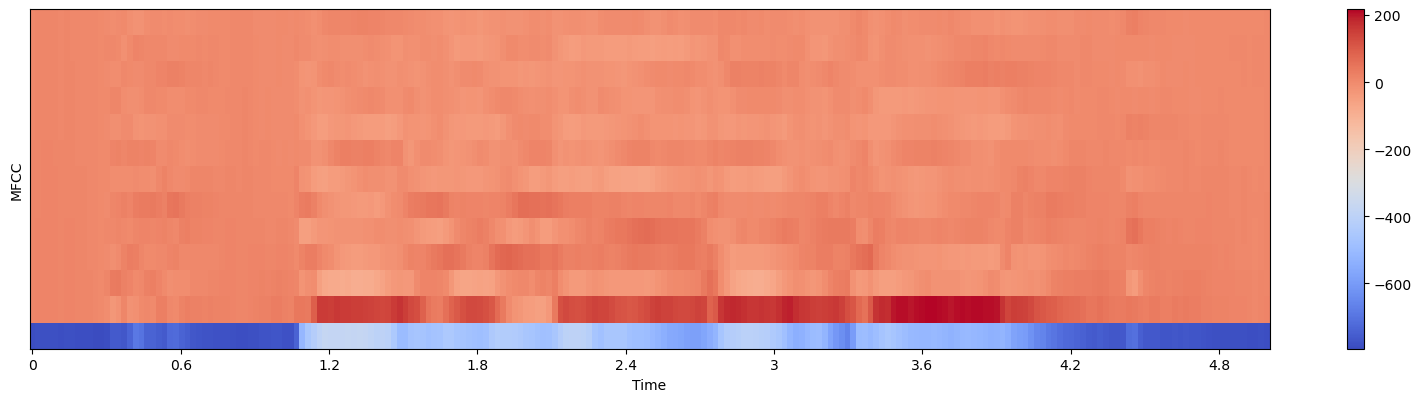

In [15]:
# Female, Happy 
file = 'data/03-01-03-01-02-02-08.wav'
signal, rate = librosa.load(file, res_type='kaiser_fast',duration=2.5,sr=22050*2,offset=0.5)  
female_happy_mfcc = librosa.feature.mfcc(y=signal, sr=rate, n_mfcc=13)

# audio wave
plt.figure(figsize=(20, 15))
plt.subplot(3,1,1)
librosa.display.waveshow(signal, sr=rate)
plt.title('Audio sampled at 44100 hrz')

# MFCC
plt.figure(figsize=(20, 15))
plt.subplot(3,1,1)
librosa.display.specshow(female_happy_mfcc, x_axis='time')
plt.ylabel('MFCC')
plt.colorbar()

ipd.Audio(file)

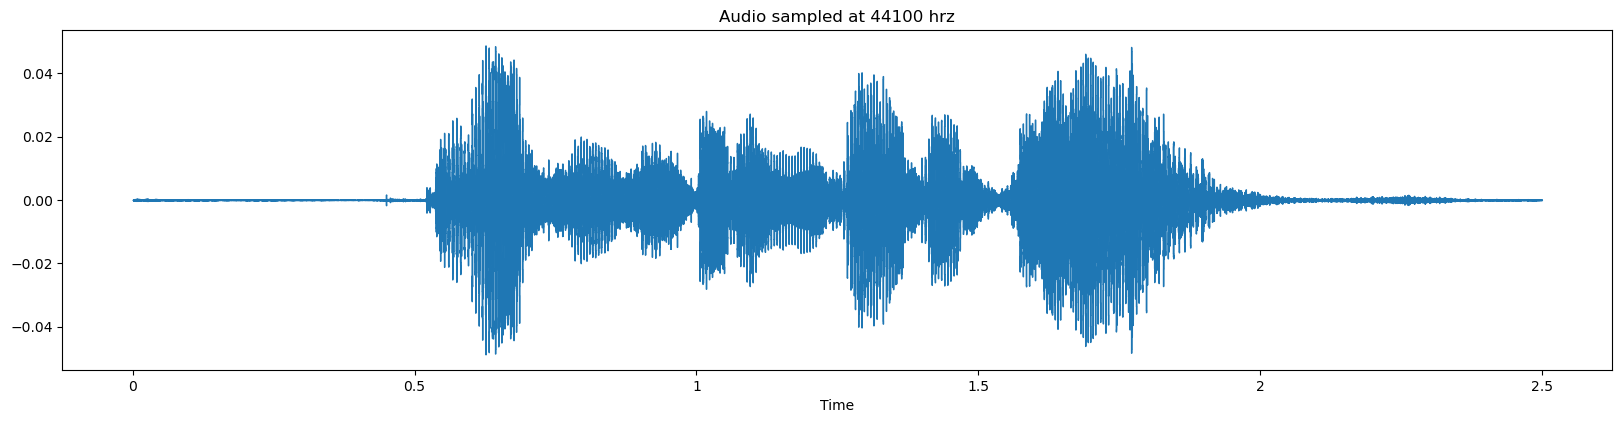

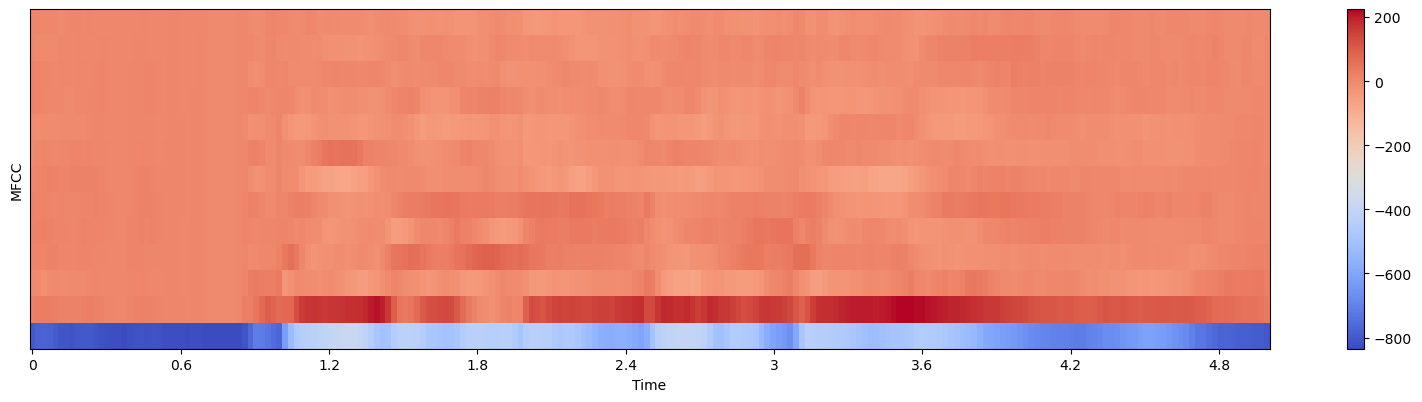

In [16]:
# Male, Happy 
file = 'data/03-01-03-01-02-02-07.wav'
signal, rate = librosa.load(file, res_type='kaiser_fast',duration=2.5,sr=22050*2,offset=0.5)  
male_happy_mfcc = librosa.feature.mfcc(y=signal, sr=rate, n_mfcc=13)

# audio wave
plt.figure(figsize=(20, 15))
plt.subplot(3,1,1)
librosa.display.waveshow(signal, sr=rate)
plt.title('Audio sampled at 44100 hrz')

# MFCC
plt.figure(figsize=(20, 15))
plt.subplot(3,1,1)
librosa.display.specshow(male_happy_mfcc, x_axis='time')
plt.ylabel('MFCC')
plt.colorbar()

ipd.Audio(file)

### How do features vary accross different emotion

The following bar plots display the average pitch and intensity levels for each emotion, accompanied by strip plots that reveal the distribution of individual samples by gender.

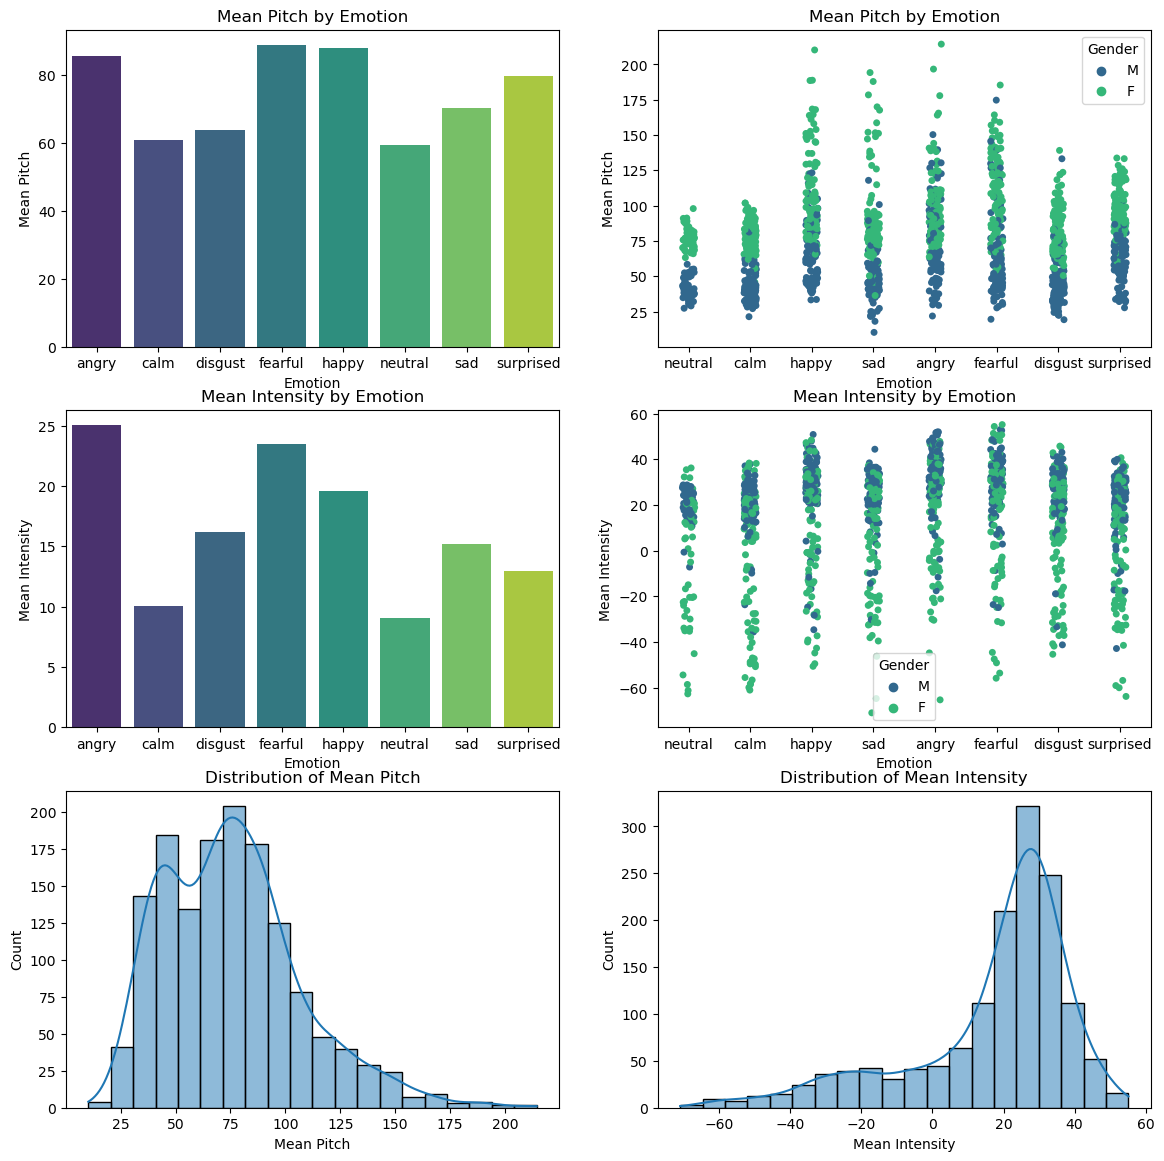

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [17]:
# Group Mean Pitch and Intensity by Emotion
pitch_means = balanced_df.groupby('Emotion')['Mean Pitch'].mean().reset_index()
intensity_means = balanced_df.groupby('Emotion')['Mean Intensity'].mean().reset_index()

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Plot for Pitch
plt.figure(figsize=(10, 6))
sns.barplot(x='Emotion', y='Mean Pitch', data=pitch_means, palette='viridis', ax=axes[0, 0])
sns.stripplot(data=df, x="Emotion", y="Mean Pitch", hue='Gender', palette='viridis', jitter=True, ax=axes[0, 1])

# Plot for Intensity
plt.figure(figsize=(10, 6))
sns.barplot(x='Emotion', y='Mean Intensity', data=intensity_means, palette='viridis', ax=axes[1, 0])
sns.stripplot(data=df, x="Emotion", y="Mean Intensity", hue='Gender', palette='viridis', jitter=True, ax=axes[1, 1])

axes[0, 0].set_title('Mean Pitch by Emotion')
axes[0, 1].set_title('Mean Pitch by Emotion')
axes[1, 0].set_title('Mean Intensity by Emotion')
axes[1, 1].set_title('Mean Intensity by Emotion')
axes[2, 0].set_title('Distribution of Mean Pitch')
axes[2, 1].set_title('Distribution of Mean Intensity')

sns.histplot(df['Mean Pitch'], bins=20, kde=True, ax=axes[2, 0])
sns.histplot(df['Mean Intensity'], bins=20, kde=True, ax=axes[2, 1])

plt.show()

Firstly, for **Mean Pitch**, the data shows that the emotions of fear, happiness, anger, and surprise have higher mean pitch values. This suggests that when a person experiences any of these emotions, they tend to use a higher tone of voice, such as squealing. In contrast, the emotions of neutral, calm, and disgust rank lower in mean pitch, which may reflect a more relaxed vocal tone. Sadness falls in the middle of the range, indicating that it can be expressed with varying tones, sometimes resembling either anger or calmness. Additionally, the strip plots reveal that the pitch of female voices is generally higher than that of male voices, although there are rare occasions when males may surpass these higher pitch levels.

On the other hand, the bar plots fo**r Average Intensi**ty levels indicate that anger and fear are expressed with greater intensity. This suggests that individuals experiencing these emotions tend to be louder than those expressing other emotions. The strip plots reveal that higher intensity levels are represented by both genders, although a small number of females display lower intensity levels.


In [18]:
# Printing values
sorted_pitch_means = pitch_means.sort_values(by='Mean Pitch', ascending=False)
sorted_intensity_means = intensity_means.sort_values(by='Mean Intensity', ascending=False)

print("Average Pitch by Emotion:")
print(sorted_pitch_means)

print("\nAverage Intensity by Emotion:")
print(sorted_intensity_means)

Average Pitch by Emotion:
     Emotion  Mean Pitch
3    fearful   88.948250
4      happy   87.920750
0      angry   85.705901
7  surprised   79.713561
6        sad   70.245641
2    disgust   63.947939
1       calm   60.963129
5    neutral   59.445957

Average Intensity by Emotion:
     Emotion  Mean Intensity
0      angry       25.018208
3    fearful       23.456459
4      happy       19.600386
2    disgust       16.154021
6        sad       15.191765
7  surprised       12.951000
1       calm       10.037127
5    neutral        9.013536


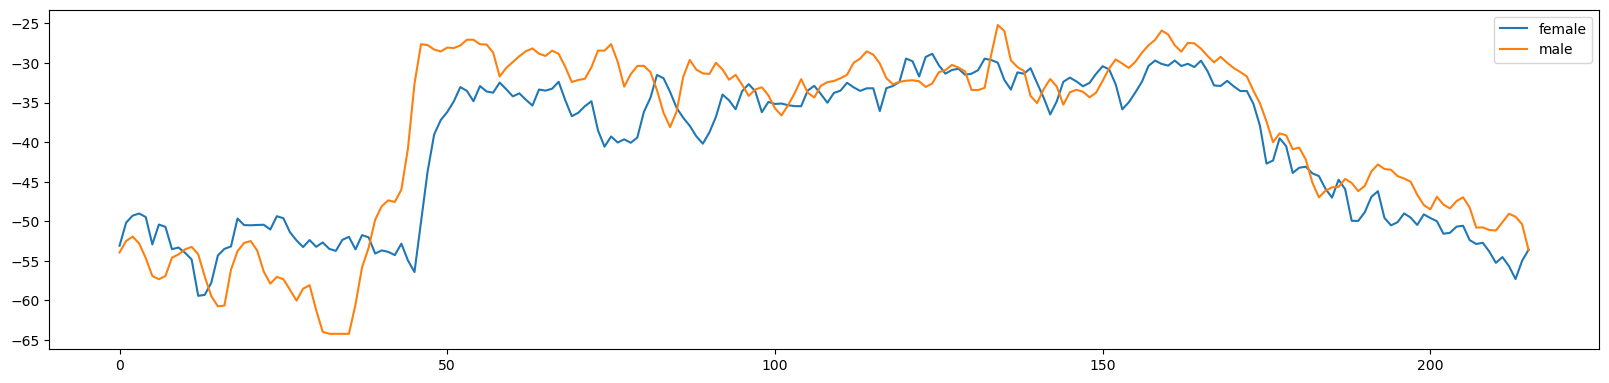

In [40]:
# MFCCs average among different emotion and gender
female_happy_mfcc_mean = np.mean(female_happy_mfcc, axis=0)
male_happy_mfcc_mean = np.mean(male_happy_mfcc, axis=0)

# print(len(female_happy_mfcc_mean))
# print(len(male_happy_mfcc_mean))

# audio wave
plt.figure(figsize=(20, 15))
plt.subplot(3,1,1)
plt.plot(female_happy_mfcc_mean, label='female')
plt.plot(male_happy_mfcc_mean, label='male')
plt.legend()
plt.show()

In this graph, we calculate the average Mel-frequency cepstral coefficients (MFCCs) for happy emotions, separated by gender. The code first computes the mean MFCC values for female and male happy audio samples using np.mean() and specifies axis=0 to average across the time dimension of the MFCCs.

### Correlations

In [19]:
# Calculations
from scipy.stats import pearsonr, spearmanr, kendalltau

# Pearson correlation
pearson_corr, _ = pearsonr(df['Mean Pitch'], df['Mean Intensity'])
print("Pearson correlation:", pearson_corr)

# Spearman correlation
spearman_corr, _ = spearmanr(df['Mean Pitch'], df['Mean Intensity'])
print("Spearman correlation:", spearman_corr)

# Kendall correlation
kendall_corr, _ = kendalltau(df['Mean Pitch'], df['Mean Intensity'])
print("Kendall correlation:", kendall_corr)

Pearson correlation: 0.008832705260363937
Spearman correlation: 0.0783363391345521
Kendall correlation: 0.05888643626596042


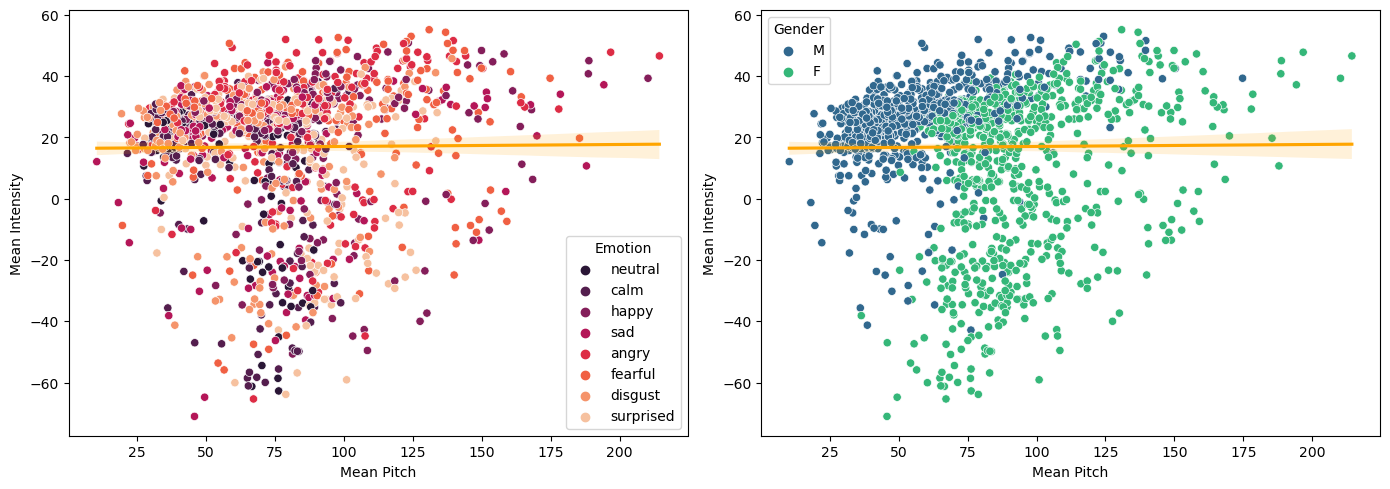

In [20]:
# Scatter plot with regression line

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='Mean Pitch', y='Mean Intensity', hue='Emotion', data=df, palette='rocket', ax=axes[0])
sns.scatterplot(x='Mean Pitch', y='Mean Intensity', hue='Gender', data=df, palette='viridis', ax=axes[1])
sns.regplot(x='Mean Pitch', y='Mean Intensity', data=df, scatter=False, color='orange', ax=axes[0])
sns.regplot(x='Mean Pitch', y='Mean Intensity', data=df, scatter=False, color='orange', ax=axes[1])
plt.tight_layout()
plt.show()

Similarly, we plotted each emotion and gender using scatter plots to examine potential correlations among them. The results indicate that none of the emotions are correlated with each other. This lack of correlation suggests that each emotion operates independently in terms of pitch and intensity, meaning that experiencing one emotion does not necessarily influence the expression of another. This finding can help us understand the distinct vocal characteristics associated with each emotion, highlighting the complexity of emotional expression.

## Model Preparation

## Extra